# Deep Reinforcement Learning (Sp25) — Lecture 21: Imitation Learning
**Instructor:** Dr. Mohammad Hossein Rohban  
**Summary by:** Amirhossein Asadi

---

## 1. Motivation: Why Imitation Learning?
In Reinforcement Learning (RL), defining a clear and effective reward function is often complex and non-trivial. This is particularly evident in domains like robotics, where specifying a reward that accurately reflects desired intricate behaviors is challenging.

* **The Reward Engineering Bottleneck:** Traditional RL often necessitates extensive "reward engineering"—designing functions to guide the agent effectively. This can constitute a significant portion of the development effort.
* **The IL Alternative:** Imitation Learning (IL) enables agents to acquire effective policies by observing **expert demonstrations**, effectively bypassing the need for explicit reward functions.

> **Note:** While IL aims to replicate expert behavior, integrating **reward shaping** (learning the reward function from demonstrations) can allow agents to eventually *surpass* the expert's performance by discovering optimal policies beyond mere imitation.

---

## 2. The Imitation Learning Setup
The general objective in IL is to learn a policy $\pi_\theta$ that closely approximates an expert policy $\pi^*$.

$$
\arg \min_\theta \mathbb{E}_{s \sim P(s|\pi_\theta)} [L (\pi^*(s), \pi_\theta(s))]
$$

This setup involves observing expert demonstrations to guide learning. The goal is to minimize the discrepancy between the learned policy and the expert's policy, enabling the agent to perform tasks without explicit reward signals.

### Key Distinctions
* **Not Standard Supervised Learning (SL):** Samples are collected from the expert policy $\pi^*$, but we aim to perform learning in the state space of the learned policy $\pi_\theta$. This discrepancy is key.
* **Not Offline RL:** A simulator is typically available, distinguishing it from purely offline RL settings.

---

## 3. Primary Methodologies

Imitation Learning generally encompasses two main approaches:

### A. Direct Approach: Behavioral Cloning (BC)
This method utilizes supervised training to directly map states to actions ($s \to a$) by learning from expert demonstrations. It learns to predict the actions taken by the expert in corresponding states.

### B. Inverse Reinforcement Learning (IRL)

In contrast to BC, IRL focuses on inferring the **underlying reward function** that the expert is presumed to be optimizing. Once this reward function is learned, standard RL techniques are employed to derive the optimal policy that maximizes it.

---

## 4. Deep Dive: Behavioral Cloning & The Distribution Mismatch
The general setup for Behavioral Cloning is:

$$
\arg \min_\theta \mathbb{E}_{(s^*, a^*) \sim P^*} [L (a^*, \pi_\theta(s^*))]
$$

### The Failure Mode: Distributional Shift
A fundamental inequality in Behavioral Cloning is that the data distribution (expert) does not match the learned policy's distribution:

$$
P_{\text{data}}(s) \neq P_{\pi_\theta} (s)
$$



Because the agent learns on expert states but acts on its own induced states, small errors compound. This mismatch causes the model to encounter **Out Of Distribution (OOD)** data, often leading to failure in sequential decision-making tasks.

---

## 5. Solutions and Advanced Techniques

To address the distribution mismatch, we generally aim to align the distributions or the policies ($\pi_\theta \to \pi^*$).

### Challenge I: Non-Markovian Experts
Humans (experts) do not always behave in a Markovian manner; decisions are influenced by past experiences and reasoning.
* **Solution:** To capture temporal dependencies, we model the policy $\pi_\theta$ using sequences of states via **LSTMs, RNNs, or Transformers**.

### Challenge II: Multimodal Behavior (Mean-Seeking)
In models like Gaussian Mixture Models (GMMs), applying Maximum Likelihood Estimation (MLE) can result in "mean-seeking" behavior. If an expert can go Left or Right to avoid an obstacle, a mean-seeking policy might average these to go Straight (into the obstacle).
* **Solution:** Discretize the action space and use **Cross-Entropy loss**. For high-dimensional action spaces, autoregressive models (chain rule) can be applied.

### The Interactive Solution: Dataset Aggregation (DAgger)


When simple alignment fails, we aim to align the data distribution with the learned policy: $P(\text{data}) \approx \pi_\theta(s)$.

**DAgger** is an iterative algorithm where the expert actively helps correct the policy:
1.  **Collect** sample trajectories using the current policy $\pi_\theta$.
2.  **Label** these new states with the *correct* expert actions (expert re-labeling).
3.  **Aggregate** this new data into the training set.

By iteratively adding corrected labels for states the agent actually visits, the agent gradually encounters the state distributions it will see during deployment, mitigating the distributional shift.

## 1. Import Required Libraries
We use PyTorch for neural networks, Gymnasium for the RL environment, and standard Python libraries for data handling and visualization.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from typing import List, Tuple
from collections import deque
import random
import os

# Set random seeds for reproducibility
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Define Expert Policy and Environment
We use the CartPole-v1 environment. The expert policy is a simple heuristic: push the cart in the direction of the pole's velocity. This is near-optimal for CartPole and serves as a stand-in for a human or pre-trained expert.

In [3]:
env = gym.make('CartPole-v1')

# Heuristic expert: push in the direction of pole velocity
class CartPoleExpert:
    def __call__(self, obs: np.ndarray) -> int:
        x, x_dot, theta, theta_dot = obs
        return int(theta_dot > 0)

expert_policy = CartPoleExpert()

## 3. Generate Expert Demonstrations
We collect state-action pairs by running the expert policy in the environment. These will be used to train the behavioral cloning agent.

In [4]:
def collect_expert_data(env: gym.Env, expert, n_episodes: int = 20) -> Tuple[np.ndarray, np.ndarray]:
    """
    Collect state-action pairs from the expert policy.
    Returns:
        states: (N, obs_dim)
        actions: (N,)
    """
    states = []
    actions = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            action = expert(obs)
            states.append(obs)
            actions.append(action)
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
    return np.array(states), np.array(actions)

expert_states, expert_actions = collect_expert_data(env, expert_policy, n_episodes=40)
print(f"Collected {len(expert_states)} expert state-action pairs.")

Collected 7833 expert state-action pairs.


## 4. Behavioral Cloning: Supervised Learning Approach
We train a neural network to imitate the expert by mapping states to actions using the collected dataset. This is a supervised learning problem.

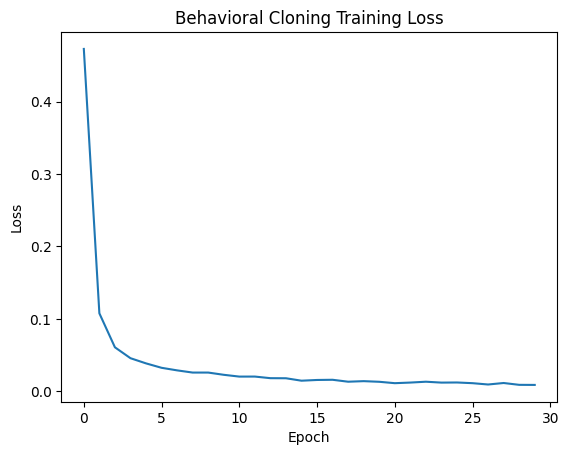

In [5]:
class BCPolicy(nn.Module):
    """Simple MLP for Behavioral Cloning."""
    def __init__(self, obs_dim: int, n_actions: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

def train_bc(policy: nn.Module, states: np.ndarray, actions: np.ndarray, epochs: int = 20, batch_size: int = 64) -> list:
    """Train the BC policy using cross-entropy loss."""
    policy.train()
    optimizer = optim.Adam(policy.parameters(), lr=1e-3)
    losses = []
    n = len(states)
    for epoch in range(epochs):
        perm = np.random.permutation(n)
        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            batch_states = torch.FloatTensor(states[idx]).to(device)
            batch_actions = torch.LongTensor(actions[idx]).to(device)
            logits = policy(batch_states)
            loss = F.cross_entropy(logits, batch_actions)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        losses.append(epoch_loss / n)
    return losses

obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
bc_policy = BCPolicy(obs_dim, n_actions).to(device)
bc_losses = train_bc(bc_policy, expert_states, expert_actions, epochs=30)
plt.plot(bc_losses)
plt.title('Behavioral Cloning Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 5. Evaluate Behavioral Cloning Policy
We deploy the trained BC policy in the environment and compare its performance to the expert.

In [6]:
def evaluate_policy(env: gym.Env, policy, n_episodes: int = 10, is_expert: bool = False) -> float:
    """Evaluate a policy (expert or BC) in the environment."""
    returns = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0.0
        while not done:
            if is_expert:
                action = policy(obs)
            else:
                obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
                with torch.no_grad():
                    logits = policy(obs_tensor)
                    action = torch.argmax(logits, dim=-1).item()
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        returns.append(total_reward)
    return np.mean(returns)

bc_return = evaluate_policy(env, bc_policy, n_episodes=20)
expert_return = evaluate_policy(env, expert_policy, n_episodes=20, is_expert=True)
print(f"Expert average return: {expert_return:.1f}")
print(f"BC policy average return: {bc_return:.1f}")

Expert average return: 206.2
BC policy average return: 208.0


## 6. Addressing Distribution Mismatch: DAgger Algorithm
Behavioral Cloning suffers from distribution mismatch: the learned policy may visit states not seen in the expert data, leading to compounding errors. DAgger (Dataset Aggregation) addresses this by iteratively collecting new data from the learned policy and querying the expert for the correct action in those states.

In [7]:
def dagger_collect(env: gym.Env, policy, expert, n_episodes: int = 10) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run the current policy, collect states, and label with expert actions.
    """
    states = []
    actions = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            obs_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
            with torch.no_grad():
                logits = policy(obs_tensor)
                action = torch.argmax(logits, dim=-1).item()
            states.append(obs)
            expert_action = expert(obs)
            actions.append(expert_action)
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
    return np.array(states), np.array(actions)

## 7. Implement DAgger and Aggregate Dataset
We alternate between running the current policy, collecting new states, labeling them with the expert, and retraining the policy on the aggregated dataset.

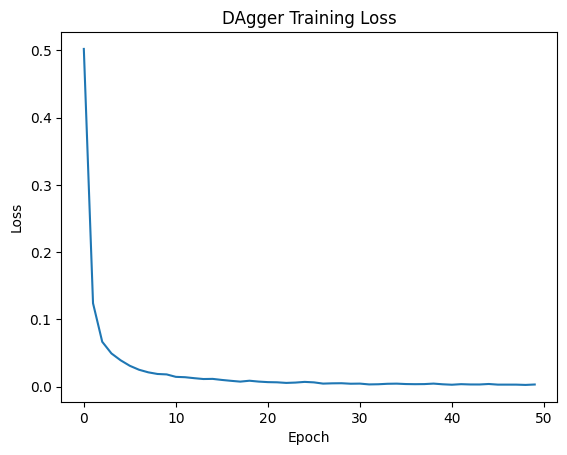

In [8]:
dagger_policy = BCPolicy(obs_dim, n_actions).to(device)
# Start with expert data
agg_states = list(expert_states)
agg_actions = list(expert_actions)
dag_losses = []
num_dagger_iters = 10
for it in range(num_dagger_iters):
    # Retrain policy on aggregated data
    states_np = np.array(agg_states)
    actions_np = np.array(agg_actions)
    losses = train_bc(dagger_policy, states_np, actions_np, epochs=5)
    dag_losses.extend(losses)
    # Collect new data using current policy, label with expert
    new_states, new_actions = dagger_collect(env, dagger_policy, expert_policy, n_episodes=5)
    agg_states.extend(new_states)
    agg_actions.extend(new_actions)
plt.plot(dag_losses)
plt.title('DAgger Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 8. Evaluate DAgger Policy
We test the final DAgger-trained policy and compare its performance to the expert and the initial BC policy.

In [9]:
dagger_return = evaluate_policy(env, dagger_policy, n_episodes=20)
print(f"DAgger policy average return: {dagger_return:.1f}")
print(f"Expert average return: {expert_return:.1f}")
print(f"BC policy average return: {bc_return:.1f}")

DAgger policy average return: 190.8
Expert average return: 206.2
BC policy average return: 208.0


## 9. Inverse Reinforcement Learning (IRL) Setup (Conceptual Code)
Inverse RL aims to infer the reward function that the expert is optimizing. Below is a conceptual outline for IRL; full implementation is beyond this notebook's scope.


In [13]:
# Improved IRL Skeleton: Educational and Feature-Rich Version
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Assume expert trajectories are already collected: expert_states, expert_actions
# 2. Define a reward network with docstring
class RewardNetwork(nn.Module):
    """Simple MLP reward function for IRL."""
    def __init__(self, obs_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

reward_net = RewardNetwork(obs_dim).to(device)
reward_optimizer = optim.Adam(reward_net.parameters(), lr=1e-3)

def collect_random_data(env, n_episodes=40):
    """Collect random (state, action) pairs from the environment."""
    states = []
    actions = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            action = env.action_space.sample()
            states.append(obs)
            actions.append(action)
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
    return np.array(states), np.array(actions)

def irl_train_step(reward_net, optimizer, expert_states, learner_states):
    """One IRL update: maximize expert reward, minimize learner reward."""
    expert_obs = torch.FloatTensor(expert_states).to(device)
    learner_obs = torch.FloatTensor(learner_states).to(device)
    expert_rewards = reward_net(expert_obs)
    learner_rewards = reward_net(learner_obs)
    loss = -expert_rewards.mean() + learner_rewards.mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item(), expert_rewards.detach().cpu().numpy(), learner_rewards.detach().cpu().numpy()

# 3. IRL training loop with re-sampling and logging
num_irl_iters = 5
losses = []
mean_expert_rewards = []
mean_learner_rewards = []
for irl_iter in range(num_irl_iters):
    learner_states, learner_actions = collect_random_data(env, n_episodes=40)
    loss, expert_r, learner_r = irl_train_step(reward_net, reward_optimizer, expert_states, learner_states)
    losses.append(loss)
    mean_expert_rewards.append(expert_r.mean())
    mean_learner_rewards.append(learner_r.mean())
    print(f"IRL iter {irl_iter+1}: loss={loss:.4f} | expert_r={expert_r.mean():.3f} | learner_r={learner_r.mean():.3f}")

print("For full IRL, see algorithms like MaxEnt IRL, AIRL, or GAIL.")

IRL iter 1: loss=0.0248 | expert_r=0.128 | learner_r=0.153
IRL iter 2: loss=-0.0136 | expert_r=0.132 | learner_r=0.118
IRL iter 3: loss=-0.0002 | expert_r=0.135 | learner_r=0.135
IRL iter 4: loss=-0.0346 | expert_r=0.139 | learner_r=0.104
IRL iter 5: loss=-0.0031 | expert_r=0.142 | learner_r=0.139
For full IRL, see algorithms like MaxEnt IRL, AIRL, or GAIL.


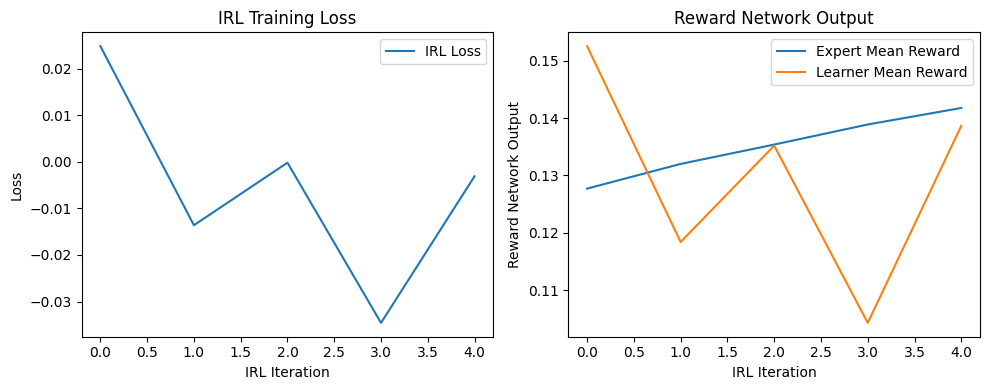

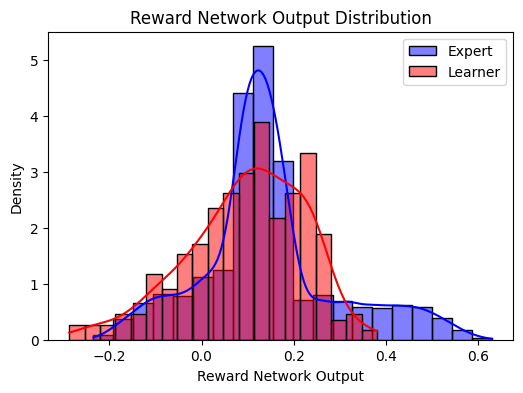

In [15]:
# Visualize IRL Reward Network Output and Training Progress
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(losses, label='IRL Loss')
plt.xlabel('IRL Iteration')
plt.ylabel('Loss')
plt.title('IRL Training Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(mean_expert_rewards, label='Expert Mean Reward')
plt.plot(mean_learner_rewards, label='Learner Mean Reward')
plt.xlabel('IRL Iteration')
plt.ylabel('Reward Network Output')
plt.title('Reward Network Output')
plt.legend()
plt.tight_layout()
plt.show()

# Show histogram of reward network outputs for expert vs. learner
import seaborn as sns
expert_obs = torch.FloatTensor(expert_states).to(device)
learner_states_vis, _ = collect_random_data(env, n_episodes=10)
learner_obs = torch.FloatTensor(learner_states_vis).to(device)
expert_r = reward_net(expert_obs).detach().cpu().numpy().flatten()
learner_r = reward_net(learner_obs).detach().cpu().numpy().flatten()
plt.figure(figsize=(6,4))
sns.histplot(expert_r, color='blue', label='Expert', kde=True, stat='density', bins=20)
sns.histplot(learner_r, color='red', label='Learner', kde=True, stat='density', bins=20)
plt.xlabel('Reward Network Output')
plt.title('Reward Network Output Distribution')
plt.legend()
plt.show()